---
## Generate House Data

In [268]:
import numpy as np
import pandas as pd
df = pd.read_csv("USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [269]:
#X = df[["Avg. Area Income",	"Avg. Area House Age", "Avg. Area Number of Rooms", "Avg. Area Number of Bedrooms", "Area Population"]]
X = df[["Avg. Area Income", "Avg. Area Number of Bedrooms"]]
y = df[['Price']]

print(f"Features: square feet and bedrooms | X shape: {X.shape}")
print(f"Target: price | y shape: {y.shape}")

Features: square feet and bedrooms | X shape: (5000, 2)
Target: price | y shape: (5000, 1)


---
## Create Training, Validation, and Test Sets

Training data fits the models, validation data chooses K, and test data is used once for final evaluation.

In [270]:
import numpy
import scipy
import sklearn

print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 1.24.4
SciPy: 1.9.1
Scikit-learn: 1.0.2


In [271]:
from sklearn.model_selection import train_test_split # Import train_test_split to divide the dataset into training, validation, and test sets.

# Split 60% of the data for training and 40% for validation/testing.
X_train, X_remaining, y_train, y_remaining = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# Split the remaining 40% equally into 20% validation data and 20% test data.
X_validation, X_test, y_validation, y_test = train_test_split(
    X_remaining, y_remaining, test_size=0.5, random_state=42
)

# Display the number of samples in each dataset.
print(f"Training: {len(X_train)} | Validation: {len(X_validation)} | Test: {len(X_test)}")

Training: 3000 | Validation: 1000 | Test: 1000


---
## Why Scaling Matters

Square feet and bedrooms have very different numeric ranges. We compare the same KNN model before and after scaling.

In [272]:
from sklearn.neighbors import KNeighborsRegressor # Import the K-Nearest Neighbors algorithm for regression problems.
from sklearn.metrics import r2_score # Import R² score to evaluate the model's prediction performance.

knn_without_scaling = KNeighborsRegressor(n_neighbors=5) # Create a KNN regression model that uses the 5 nearest neighbors.
knn_without_scaling.fit(X_train, y_train) # Train the KNN model using the training features and their actual house prices.
prediction_without_scaling = knn_without_scaling.predict(X_validation) # Use the trained model to predict house prices for the validation data.

# R² measures how well the model explains the variation in the actual target values; closer to 1 means better performance.
print(f"Validation R² without scaling: {r2_score(y_validation, prediction_without_scaling):.3f}")

Validation R² without scaling: 0.268


In [273]:
from sklearn.preprocessing import StandardScaler # Import StandardScaler to standardize the numerical features.
from sklearn.pipeline import Pipeline # Import Pipeline to combine multiple machine learning steps into one workflow.

# Create a pipeline that first scales the data and then applies KNN regression.
scaled_knn = Pipeline([
    ("scaler", StandardScaler()), # Standardize each feature using the training data's mean and standard deviation.    
    ("knn", KNeighborsRegressor(n_neighbors=5))
])


scaled_knn.fit(X_train, y_train) # Train the pipeline on the training data; scaling is fitted only on X_train.
prediction_with_scaling = scaled_knn.predict(X_validation) # Scale the validation features using the fitted scaler and predict their house prices.

# Calculate and display the R² score to measure the model's performance on validation data.
print(f"Validation R² with scaling: {r2_score(y_validation, prediction_with_scaling):.3f}")

Validation R² with scaling: 0.307


---
## Choose K Using Validation MSE

Fit each candidate on the training set and choose the K with the lowest validation MSE. The test set remains untouched.

In [274]:
from sklearn.metrics import mean_squared_error # Import Mean Squared Error (MSE) to measure the model's prediction error.


k_values = list(range(1, 31)) # Create K values from 1 to 30 to find the best number of neighbors.
validation_mse = [] # Create an empty list to store the validation MSE for each K value.

for k in k_values:

    # Create a pipeline that scales the features and then applies KNN regression.
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])

    model.fit(X_train, y_train) # Train the model using the training data.   
    validation_prediction = model.predict(X_validation)  # Predict house prices for the validation dataset.
    validation_mse.append(mean_squared_error(y_validation, validation_prediction))  # Calculate and store the validation MSE for the current K value.

best_k = k_values[np.argmin(validation_mse)] # Select the K value that produces the lowest validation MSE.

# Display the selected K value.
print(f"Selected K: {best_k}")

# Display the lowest validation MSE achieved among all tested K values.
print(f"Lowest validation MSE: {min(validation_mse):,.0f}")

Selected K: 30
Lowest validation MSE: 71,630,852,799


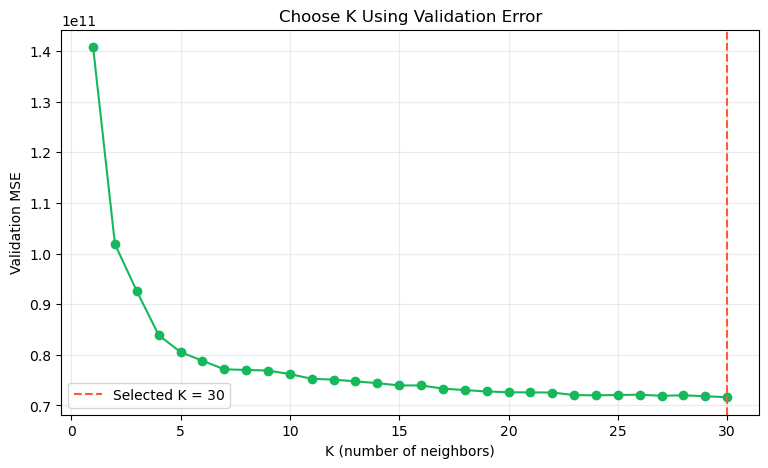

In [275]:
import matplotlib.pyplot as plt # Import Matplotlib for creating plots.

plt.figure(figsize=(9, 5))                                                               # Create a figure with a width of 9 and height of 5.
plt.plot(k_values, validation_mse, color="#16B85C", marker="o")                        # Plot validation MSE for each K value.
plt.axvline(best_k, color="#FF5A36", linestyle="--", label=f"Selected K = {best_k}")   # Draw a vertical line at the selected best K, Add a label showing the selected K value.
plt.xlabel("K (number of neighbors)")                                                    # Set the X-axis label.
plt.ylabel("Validation MSE")                                                             # Set the Y-axis label.
plt.title("Choose K Using Validation Error")                                             # Set the title of the plot.
plt.legend()                                                                             # Display the legend.
plt.grid(alpha=0.25)                                                                     # Add a light grid to the plot.
plt.show()                                                                               # Display the plot.

---
## Fit the Final Pipeline and Evaluate Once

K is now locked. Combine the training and validation sets, refit the Pipeline, and evaluate it once on the untouched test set.

In [276]:
X_final_train = np.vstack([X_train, X_validation]) # Combine the training and validation features to create the final training dataset.
y_final_train = np.concatenate([y_train, y_validation]) # Combine the training and validation target values (house prices).

# Create the final pipeline with feature scaling followed by KNN regression.
final_pipeline = Pipeline([
    ("scaler", StandardScaler()), # Standardize all features before applying KNN.
    ("knn", KNeighborsRegressor(n_neighbors=best_k)) # Create the KNN model using the best K value selected during validation.
])

final_pipeline.fit(X_final_train, y_final_train) # Train the final pipeline using both training and validation data.
test_prediction = final_pipeline.predict(X_test) # Use the final trained model to predict prices for the unseen test data.

# Display the K value selected during the validation process.
print(f"Final K: {best_k}")

# Calculate and display the Mean Squared Error (MSE) on the test data.
print(f"Test MSE: {mean_squared_error(y_test, test_prediction):,.0f}")

# Calculate and display the R² score on the test data.
print(f"Test R²: {r2_score(y_test, test_prediction):.3f}")

Final K: 30
Test MSE: 69,571,824,662
Test R²: 0.448


/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


---
## Save and Load the Fitted Pipeline

The fitted StandardScaler and KNN model are saved together in one file.

In [277]:
# Import joblib to save and load the trained machine learning pipeline.
import joblib

# Save the trained pipeline to a file so it can be reused later without retraining.
joblib.dump(final_pipeline, "house_price_pipeline.joblib")

# Load the saved pipeline back into memory.
loaded_pipeline = joblib.load("house_price_pipeline.joblib")

# Confirm that the pipeline was successfully saved and loaded.
print("Saved and loaded house_price_pipeline.joblib")

Saved and loaded house_price_pipeline.joblib


---
## Create the Prediction Function

The function receives user values, calls the fitted Pipeline, and returns a readable result.

In [278]:
# Define a function to predict the house price from the input features.
def predict_price(sq_feet, bedrooms):

    house = np.array([[sq_feet, bedrooms]]) # Create a NumPy array containing the input features.
    prediction = loaded_pipeline.predict(house)[0] # Predict the house price using the loaded pipeline.
    prediction = prediction.item() if isinstance(prediction, np.ndarray) else prediction # Convert the prediction to a single number if it is still a NumPy array.

    # Return the predicted price formatted as US currency.
    return f"Predicted price: ${prediction:,.0f}"

# Predict the price of a 2,000 sq. ft. house with 3 bedrooms.
predict_price(2000, 3)

'Predicted price: $663,422'

---
## Visualize the Selected Neighbors

Because the Pipeline scales the features before KNN, the plot uses standardized feature values. The highlighted labels show the known prices that are averaged for the prediction.

In [279]:
def predict_with_neighbors(sq_feet, bedrooms):
    house = np.array([[sq_feet, bedrooms]])
    prediction = loaded_pipeline.predict(house)[0]

    # 🟢 ADDED: Convert prediction to a single number if it is a NumPy array.
    if isinstance(prediction, np.ndarray):
        prediction = prediction.item()

    scaler = loaded_pipeline.named_steps["scaler"]
    knn = loaded_pipeline.named_steps["knn"]
    scaled_training = scaler.transform(X_final_train)
    scaled_house = scaler.transform(house)
    _, indices = knn.kneighbors(scaled_house)
    neighbors = indices[0]

    fig, ax = plt.subplots(figsize=(8, 5)) # Create a figure and axes for the scatter plot.
    ax.scatter(scaled_training[:, 0], scaled_training[:, 1], color="#AAB8C8", alpha=0.55, label="Other houses")  # Plot all training houses as points on the graph.
    ax.scatter(scaled_training[neighbors, 0], scaled_training[neighbors, 1], color="#16B85C", s=110, label=f"{best_k} nearest neighbors") # Highlight the nearest neighbors of the new house.
    ax.scatter(scaled_house[0, 0], scaled_house[0, 1], color="#FF5A36", marker="*", s=260, label="New house") # Plot the new house as a star on the graph.

    # Loop through each nearest neighbor.
    for index in neighbors:
        # Draw a dashed line between the new house and the neighbor.
        ax.plot([scaled_house[0, 0], scaled_training[index, 0]], [scaled_house[0, 1], scaled_training[index, 1]], color="#16B85C", linestyle="--", alpha=0.5)
        # Display the actual price of the neighbor next to its point.
        ax.annotate(
            f"${y_final_train[index].item():,.0f}",  # .item() extracts the number from the NumPy array.
            (scaled_training[index, 0], scaled_training[index, 1]),
            xytext=(5, 6),
            textcoords="offset points"
        )

    ax.set_xlabel("Standardized square feet") # Set the label for the X-axis.
    ax.set_ylabel("Standardized bedrooms")  # Set the label for the Y-axis.
    ax.set_title(f"Prediction = average of {best_k} neighbor prices = ${prediction:,.0f}")  # Set the plot title showing the predicted price and number of neighbors.
    ax.legend()  # Display the labels for the different types of points.
    ax.grid(alpha=0.2)  # Add a light grid to make the graph easier to read.
    fig.tight_layout() # Adjust the spacing so that all plot elements fit properly.

    return f"Predicted price: ${prediction:,.0f}", fig # Return the predicted price as text and the generated plot.

---
## Build One Gradio Interface

Run the installation cell only when Gradio is not already available.

<class 'tuple'>
('Predicted price: $661,194', <Figure size 800x500 with 1 Axes>)


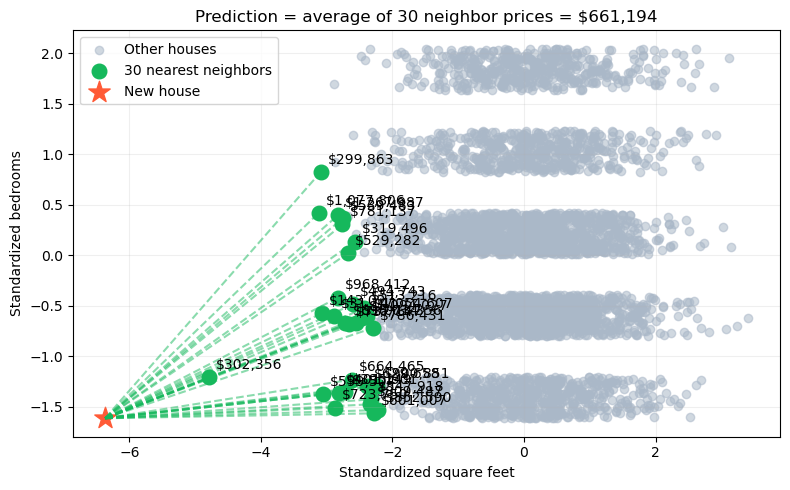

In [280]:
# Import Gradio to create the web interface.
import gradio as gr

# Create the Gradio interface.
demo = gr.Interface(

    fn=predict_with_neighbors,

    # Define the input components.
    inputs=[
        gr.Slider(500, 3000, value=2000, step=10, label="Square feet"),  # Create a slider for entering the house size in square feet.       
        gr.Slider(1, 5, value=3, step=1, label="Bedrooms")  # Create a slider for entering the number of bedrooms.
    ],

    # Define the output components.
    outputs=[
        gr.Textbox(label="Prediction"), # Display the predicted house price as text.
        gr.Plot(label="Selected neighbors", format="png") # Display the selected nearest neighbors plot as a PNG image.
    ],

    title="House Price Predictor",
    description=f"Uses the K = {best_k} selected from validation data."
)

result = predict_with_neighbors(1000, 2)
print(type(result))
print(result)

In [281]:
demo.launch(share=True, debug=True)

Running on local URL:  http://127.0.0.1:7860
Running on public URL: https://32eb88958ea5e4cd4b.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://32eb88958ea5e4cd4b.gradio.live
